In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# set random seed for reproducibility
np.random.seed(0)

# set solve_ivp keyword arguments
solve_ivp_kwargs = {}
solve_ivp_kwargs['method'] = 'RK45'
solve_ivp_kwargs['rtol'] = 1e-6
solve_ivp_kwargs['atol'] = 1e-6

A comment on data formatting:
- data arrays should take the form $[x(t_1), x(t_2), ..., x(t_n)]$
- thus, arrays should have the form (rows, cols) == (n_state_vars, n_samples)
    - so, x[0] should be many samples of the first state variable

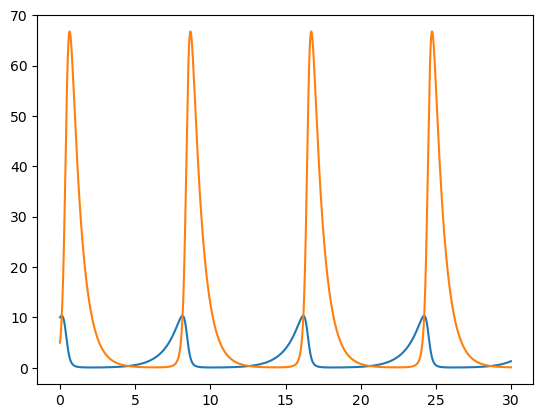

In [2]:
# generate Lotka-Volterra right-hand side functions
def generate_lotka_volterra_rhs(a, b, c, d):
    def lotka_volterra_rhs(t, x):
        # we expect x to be a 2D array with shape (rows, cols) == (2, n_samples)
        assert x.shape[0] == 2
        return np.array([a*x[0] - b*x[0]*x[1], -c*x[1] + d*x[0]*x[1]])
    return lotka_volterra_rhs

# make a specific Lotka-Volterra right-hand side function
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

# generate general training data
def generate_training_data(rhs, t_span, dt, x0):
    t_train = np.arange(t_span[0], t_span[1], dt)
    x_train = solve_ivp(rhs, t_span, x0, t_eval=t_train, **solve_ivp_kwargs).y
    # NOTE: x_train.shape == (n_samples, n_state_vars) == (rows, cols)
    return t_train, x_train

dt = 0.01
t_span = (0, 30)
x0_train = (10, 5)
t_train, x_train = generate_training_data(lotka_volterra_rhs, t_span=t_span, dt=dt, x0=x0_train)

plt.plot(t_train, x_train.T)

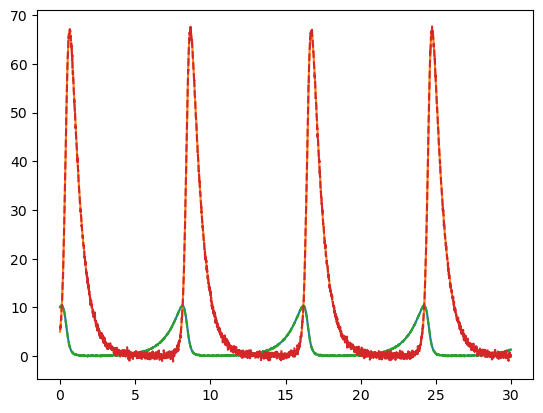

In [3]:
def generate_noisy_data(x, noise_level):
    # set random seed for reproducibility
    np.random.seed(0)

    # calculate the root-mean-square (RMS) value of each state variable
    rms = np.reshape(np.sqrt(np.mean(x**2, axis=1)), (-1, 1))
    
    # calculate the standard deviation of the noise to add
    std = rms * noise_level

    # generate appropriate noise by scaling samples from a standard normal
    # NOTE: because "std" is a vector it gets broadcast to the shape of the standard normal noise
    noise = std * np.random.standard_normal(x.shape)
    
    return x + noise


x_train_noisy = generate_noisy_data(x_train, 0.02)
plt.plot(t_train, x_train.T)
plt.plot(t_train, x_train_noisy.T, '--')

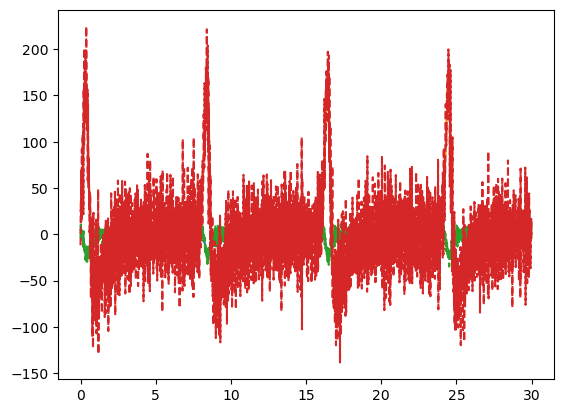

In [4]:
from derivative import dxdt

# generate the true derivative
x_dot_true = lotka_volterra_rhs(t_train, x_train)

# x_dot_approx = dxdt(x_train_noisy, t_train, kind="savitzky_golay", left=.5, right=.5, order=3)
x_dot_approx = dxdt(x_train_noisy, t_train, kind="finite_difference", k=1)

plt.plot(t_train, x_dot_true.T)
plt.plot(t_train, x_dot_approx.T, '--')

In [5]:
import pysindy as ps
from tqdm import tqdm

poly_order = 5
threshold = 0.02 # NOTE: was 0.5 in demo notebook

noise_levels = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1]
# noise_levels = [0, 1e-4, 1e-3, 1e-2, 2e-2]

models = []
for noise_level in tqdm(noise_levels):
    # generate noisy data
    x_train_noisy = generate_noisy_data(x_train, noise_level)
    
    # generate the derivative of the noisy data
    # NOTE: we can change the kind of derivative and the parameters of the derivative method!
    x_dot_approx = dxdt(x_train_noisy, t_train, kind="finite_difference", k=1)

    # create a SINDy model
    model = ps.SINDy(
        optimizer=ps.STLSQ(threshold=threshold),
        feature_library=ps.PolynomialLibrary(degree=poly_order),
    )

    # fit the SINDy model
    model.fit(x_train_noisy.T, t=t_train, x_dot=x_dot_approx.T, quiet=True)

    # append the model to the list of models
    models.append(model)


# print the models
for i in range(len(noise_levels)):
    print(f"noise level: {noise_levels[i]}")
    models[i].print(lhs=["x", "y"])
    print()

100%|██████████| 6/6 [00:01<00:00,  4.52it/s]

noise level: 0
x = 1.000 x0 + -0.100 x0 x1
y = -15.298 1 + 9.213 x0 + -0.040 x1 + -0.111 x0^2

noise level: 0.0001
x = 1.000 x0 + -0.100 x0 x1
y = -1.500 x1 + 0.750 x0 x1

noise level: 0.001
x = 0.999 x0 + -0.100 x0 x1
y = -1.500 x1 + 0.750 x0 x1

noise level: 0.01
x = 0.998 x0 + -0.100 x0 x1
y = -1.499 x1 + 0.750 x0 x1

noise level: 0.1
x = 0.093 1 + -0.363 x0 + 0.022 x0^2
y = -0.184 1 + -1.423 x0 + -1.426 x1 + 0.616 x0^2 + 0.718 x0 x1 + -0.049 x0^3

noise level: 1
x = 0.666 1 + -0.432 x0 + -0.111 x1 + 0.034 x0^2
y = -16.387 1 + 10.195 x0 + 0.402 x0^2 + -0.272 x0 x1 + -0.101 x0^3 + 0.036 x0^2 x1



In [20]:
def generate_model_prediction(model, t_span, dt, x0):
    def model_rhs(t, x):
        return model.predict(x.reshape((1, -1))).reshape(-1)
    
    t_eval = np.arange(t_span[0], t_span[1], dt)
    ivp_result = solve_ivp(model_rhs, t_span, x0, t_eval=t_eval, **solve_ivp_kwargs)
    x_pred = ivp_result.y
    
    return t_eval, x_pred

dt = 0.01
t_span = (0, 50)
x0_eval = (10, 5)

t_evals = []
x_preds = []
for model in tqdm(models):
    t_eval, x_pred = generate_model_prediction(model, t_span=t_span, dt=dt, x0=x0_eval)
    t_evals.append(t_eval)
    x_preds.append(x_pred)

 17%|█▋        | 1/6 [00:03<00:15,  3.11s/it]

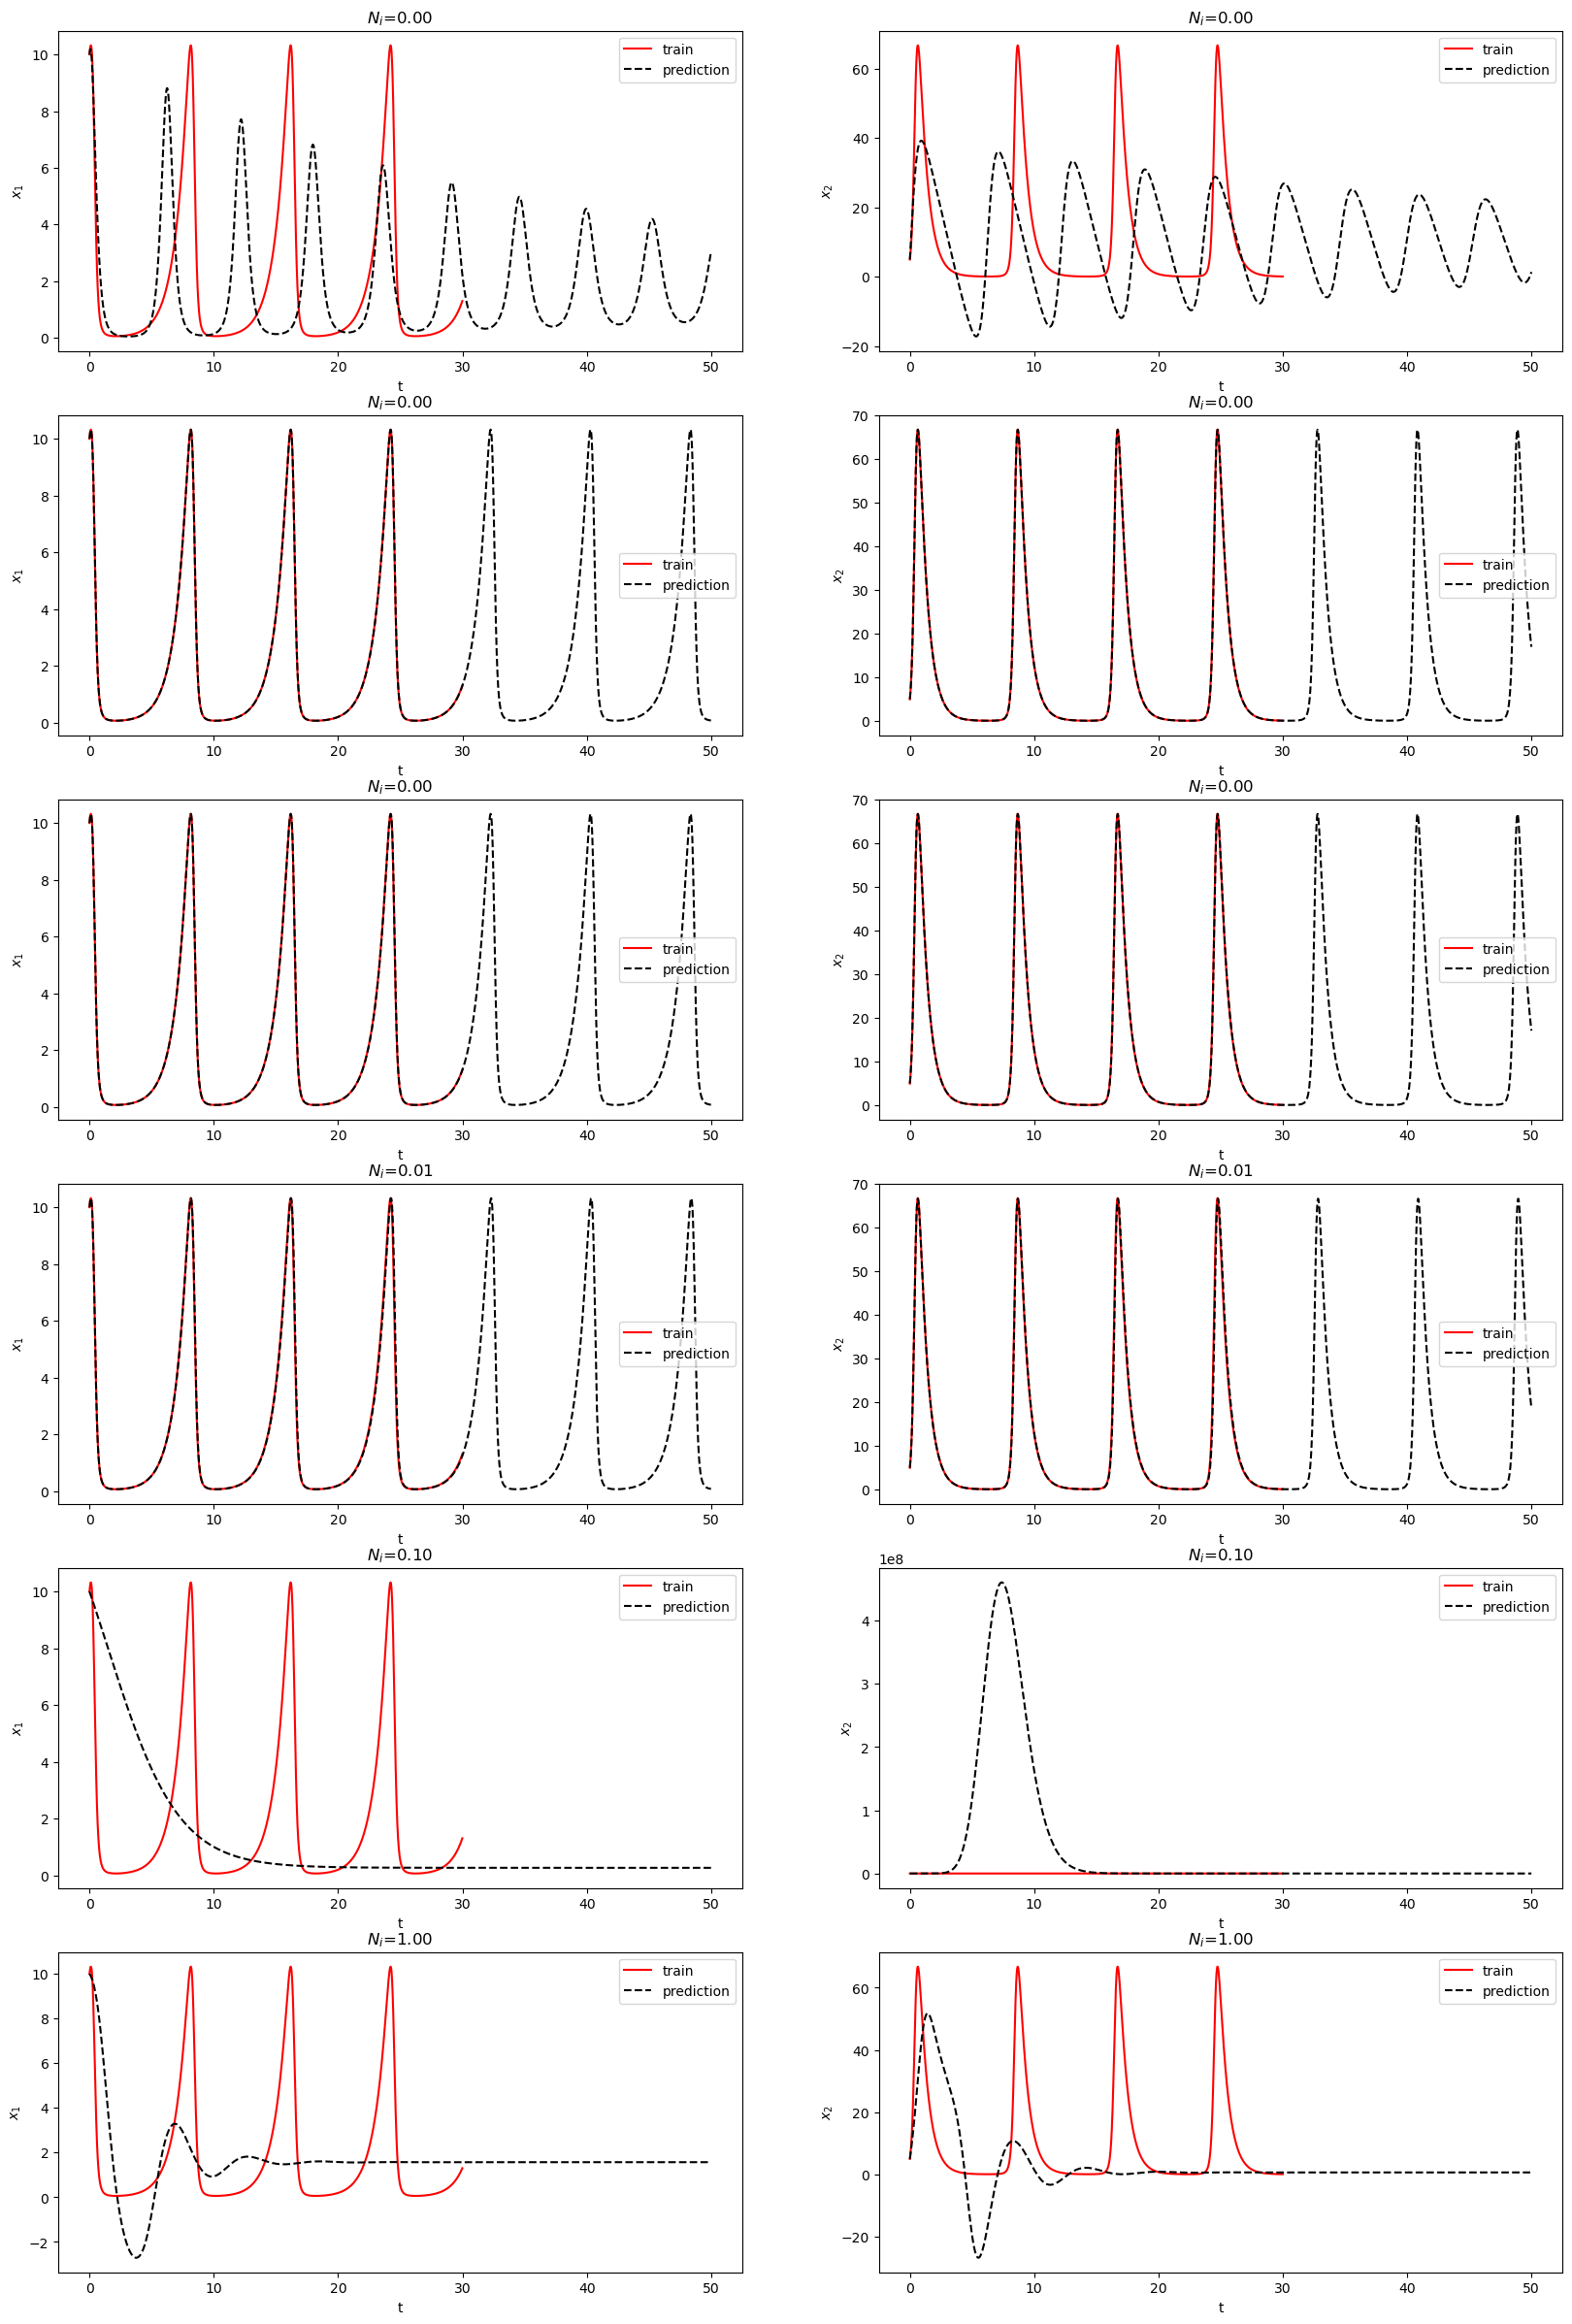

In [21]:
n_rows = len(noise_levels)
n_cols = 2

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 5*n_rows))

for row in range(n_rows):
    # each row corresponds to a different noise level

    for col in range(n_cols):
        # plot the col'th training state variable
        axs[row, col].plot(t_train, x_train[col], "r", label="train")
        
        # plot the col'th state variable model prediction
        axs[row, col].plot(t_evals[row], x_preds[row][col], "k--", label="prediction")

        # set the title and labels
        axs[row, col].set_title(f"$N_i$={noise_levels[row]:.2f}")
        axs[row, col].set_xlabel("t")
        axs[row, col].set_ylabel(f"$x_{col + 1}$")
        axs[row, col].legend()

fig.show()